# Vanishing Gradient Problem

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [95]:
X,y = make_moons(n_samples = 250, noise = 0.05, random_state = 42)

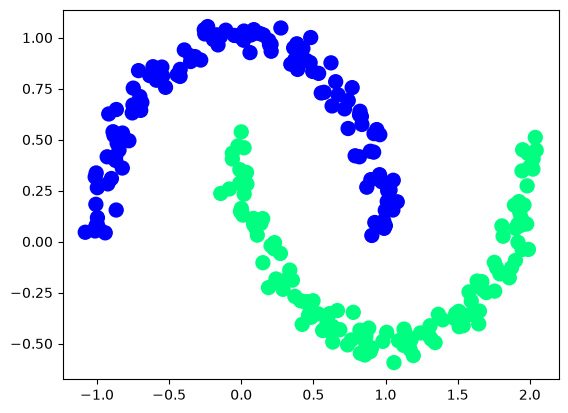

In [96]:
plt.scatter(X[:,0],X[:,1], c= y, cmap = 'winter', s = 100)
plt.show()

In [97]:
model = Sequential()

In [98]:
model.add(Dense(10, activation = 'relu', input_dim = 2))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10,activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(1,  activation = 'sigmoid'))

d:\DeepLearning.py\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [99]:
model.compile(loss= 'binary_crossentropy', optimizer = 'adam',metrics= ['accuracy'])

In [100]:
model.get_weights()

[array([[ 0.16483176,  0.37472612, -0.0427475 ,  0.34624714,  0.38208312,
         -0.02086067, -0.47128302, -0.08994859, -0.5037415 ,  0.01522952],
        [-0.6587524 ,  0.42560273, -0.3021177 , -0.41421854,  0.69130474,
         -0.56530994, -0.3192492 , -0.1778912 , -0.22986048, -0.5542518 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.37546247,  0.40612203,  0.15688097, -0.52903473,  0.17395842,
          0.24220914,  0.35522223,  0.01695114, -0.0827415 ,  0.22001314],
        [-0.10526323, -0.34603882, -0.4635395 ,  0.19465452, -0.29854554,
         -0.14885208,  0.4753425 ,  0.54543495,  0.09928471, -0.34512377],
        [-0.09812248,  0.16303009,  0.12199616,  0.12164217, -0.3451059 ,
          0.50463045, -0.27271512, -0.41172838, -0.5214398 , -0.37738967],
        [-0.16628665,  0.2062316 ,  0.0467732 , -0.18183869, -0.16870919,
          0.1058082 ,  0.30990726, -0.47655803, -0.32971358,  0.10092419],
        [-0.49451

In [101]:
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 42)

In [102]:
old_weights = model.get_weights()[0]

In [103]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5400 - loss: 0.6952
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5800 - loss: 0.6936
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6000 - loss: 0.6921
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6650 - loss: 0.6910 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5500 - loss: 0.6897 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5600 - loss: 0.6875
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6900 - loss: 0.6835 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5100 - loss: 0.6772 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6050 - loss: 0.6646  
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7700 - loss: 0.6484
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8050 - loss: 0.6296
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8050 - l

In [104]:
from sklearn.metrics import accuracy_score

In [105]:
y_prob = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step


In [106]:
y_pred = np.where(y_prob > 0.5 , 1,0)


In [107]:
print("accuracy_score: ", accuracy_score(y_test, y_pred))

accuracy_score:  1.0


In [108]:
new_weights = model.get_weights()[0]

In [109]:
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [110]:
gradient = (old_weights - new_weights)/2
percentage_change = abs(100 * (old_weights - new_weights)/old_weights)

In [111]:
old_weights

array([[ 0.16483176,  0.37472612, -0.0427475 ,  0.34624714,  0.38208312,
        -0.02086067, -0.47128302, -0.08994859, -0.5037415 ,  0.01522952],
       [-0.6587524 ,  0.42560273, -0.3021177 , -0.41421854,  0.69130474,
        -0.56530994, -0.3192492 , -0.1778912 , -0.22986048, -0.5542518 ]],
      dtype=float32)

In [112]:
new_weights

array([[ 0.27411523,  0.42876884,  0.09241836,  0.46213597,  0.40908492,
         0.03579094, -0.7283043 , -0.07206286, -0.70501846,  0.21275727],
       [-0.46792927,  0.2864292 , -0.28729534, -0.32576802,  0.86886626,
        -0.8159447 , -0.08115138, -0.1696001 ,  0.07116093, -0.5791529 ]],
      dtype=float32)

In [113]:
gradient

array([[-0.05464174, -0.02702136, -0.06758293, -0.05794442, -0.0135009 ,
        -0.02832581,  0.12851065, -0.00894287,  0.10063848, -0.09876388],
       [-0.09541155,  0.06958677, -0.00741118, -0.04422526, -0.08878076,
         0.12531736, -0.11904892, -0.00414555, -0.15051071,  0.01245055]],
      dtype=float32)

In [114]:
percentage_change

array([[  66.30001  ,   14.4219265,  316.19595  ,   33.469975 ,
           7.066996 ,  271.57135  ,   54.53651  ,   19.8844   ,
          39.956398 , 1297.0055   ],
       [  28.967352 ,   32.70034  ,    4.906155 ,   21.353586 ,
          25.684986 ,   44.335808 ,   74.58056  ,    4.6607676,
         130.95831  ,    4.49274  ]], dtype=float32)

In [118]:
from sklearn.metrics import roc_auc_score, roc_curve

In [119]:
fpr , tpr, thresholds = roc_curve(y_test, y_prob)

In [120]:
optimal_index = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_index]

In [121]:
optimal_threshold

np.float64(0.9963381290435791)